In [ ]:
from sklearn.datasets import load_diabetes
import numpy as np
from itertools import product
import pandas as pd
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

In [ ]:
%config InlineBackend.figure_format = 'svg'

# Getting toy data

In [ ]:
d = pd.read_csv('heart_failure_clinical_records_dataset.csv')

In [ ]:
d.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='object')

In [ ]:
d.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [ ]:
categrical_features=['anaemia','diabetes','high_blood_pressure','sex', 'smoking']

In [ ]:
continuous_features=[]
for column in (d.columns):

    if column not in categrical_features and column!='DEATH_EVENT':
        continuous_features.append(column)

In [ ]:
data=np.array(d[['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']])
target=np.array(d[['DEATH_EVENT']])

In [ ]:
data.shape

(299, 12)

In [ ]:
target.shape

(299, 1)

# Dividing data into training and test data

In [ ]:
np.random.seed(42)
random_permutation=np.random.permutation(len(data))

In [ ]:
data=data[random_permutation]
target=target[random_permutation]

In [ ]:
training_ratio=0.8
r=int(len(data)*training_ratio)

In [ ]:
data_train=data[:r]
target_train=target[:r]

data_test=data[r:]
target_test=target[r:]

In [ ]:
clf=RandomForestClassifier(max_depth=2, random_state=0)
clf.fit(data_test, target_test.flatten())

RandomForestClassifier(max_depth=2, random_state=0)

In [ ]:
predictions = clf.predict_proba(data_test)[:,1]

In [ ]:
predictions

array([0.13796938, 0.11546504, 0.42878386, 0.48429839, 0.10139642,
       0.31990301, 0.47532021, 0.11113012, 0.73556356, 0.39777472,
       0.44321057, 0.12224118, 0.52780918, 0.32886665, 0.13390323,
       0.53586967, 0.29106029, 0.21978983, 0.15909256, 0.48055683,
       0.12367977, 0.70513489, 0.12690719, 0.49366204, 0.11230924,
       0.08662859, 0.10858808, 0.11692495, 0.20322146, 0.1909595 ,
       0.64892938, 0.63434574, 0.09882482, 0.1193459 , 0.12076073,
       0.46205433, 0.14844767, 0.61805386, 0.78624104, 0.17374363,
       0.107521  , 0.56027975, 0.13152467, 0.15591379, 0.12798971,
       0.11386946, 0.12795136, 0.15710716, 0.10101411, 0.13976361,
       0.13463463, 0.12911449, 0.17483838, 0.15744891, 0.49109559,
       0.1652683 , 0.10608197, 0.12575786, 0.17355836, 0.23947431])

In [ ]:
def get_discrete_predictions(prediction_probabilities, threshold=0.5):
    y_pred=(predictions>threshold).flatten()*1
    return y_pred

In [ ]:
y_pred=get_discrete_predictions(predictions, 0.34)

In [ ]:
y_pred

array([0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

In [ ]:
y_true=target_test.flatten()

In [ ]:
y_true

array([0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

# Confusion Matrix

The **confusion matrix** is a table used to evaluate the performance of a classification algorithm by comparing its predictions against actual outcomes. It provides a detailed breakdown of correct and incorrect classifications, helping to calculate various performance metrics.

## Structure of a Confusion Matrix

For a binary classification problem, the confusion matrix is a $2 \times 2$ table with the following components:

|                | **Predicted Positive** | **Predicted Negative** |
|----------------|-------------------------|-------------------------|
| **Actual Positive** | True Positive (TP)         | False Negative (FN)         |
| **Actual Negative** | False Positive (FP)         | True Negative (TN)          |

- **True Positive (TP):** Correctly predicted positive cases.
- **True Negative (TN):** Correctly predicted negative cases.
- **False Positive (FP):** Number of incorrectly predicted negative cases as positive cases (Type I error).
- **False Negative (FN):** Number of incorrectly predicted positive cases negative cases (Type II error).

---

## Key Metrics Derived from the Confusion Matrix

1. **Accuracy**  
   Measures the overall correctness of the model.

   $$
   \text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}
   $$

2. **Precision** (Positive Predictive Value)  
   Measures how many predicted positives are actually positive.

   $$
   \text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}
   $$

3. **Recall/Sensitivity** (True Positive Rate)  
   Measures how many actual positives are correctly predicted.

   $$
   \text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}
   $$

4. **F1 Score**  
   Harmonic mean of precision and recall, balancing the two.

   $$
   \text{F1 Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
   $$

5. **Specificity** (True Negative Rate)  
   Measures how many actual negatives are correctly predicted.

   $$
   \text{Specificity} = \frac{\text{TN}}{\text{TN} + \text{FP}}
   $$

6. **False Positive Rate (FPR)**  
   Measures the proportion of actual negatives that are incorrectly predicted as positive.

   $$
   \text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}
   $$

7. **False Negative Rate (FNR)**  
   Measures the proportion of actual positives that are incorrectly predicted as negative.

   $$
   \text{FNR} = \frac{\text{FN}}{\text{FN} + \text{TP}}
   $$

---

In [ ]:
def calculate_confusion_matrix(y_true, y_pred):
    """
    Calculate the confusion matrix from true and predicted targets.

    Parameters:
        y_true (numpy.ndarray): Array of true target values (binary: 0 or 1).
        y_pred (numpy.ndarray): Array of predicted target values (binary: 0 or 1).

    Returns:
        numpy.ndarray: A 2x2 confusion matrix where:
            confusion_matrix[0, 0] = True Negative (TN)
            confusion_matrix[0, 1] = False Positive (FP)
            confusion_matrix[1, 0] = False Negative (FN)
            confusion_matrix[1, 1] = True Positive (TP)
    """
    # Ensure inputs are numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Validate that both arrays have the same length
    if len(y_true) != len(y_pred):
        raise ValueError("y_true and y_pred must have the same length.")

    # Calculate components of the confusion matrix
    TN = np.sum((y_true == 0) & (y_pred == 0))  # True Negatives
    FP = np.sum((y_true == 0) & (y_pred == 1))  # False Positives
    FN = np.sum((y_true == 1) & (y_pred == 0))  # False Negatives
    TP = np.sum((y_true == 1) & (y_pred == 1))  # True Positives

    # Construct the confusion matrix
    confusion_matrix = np.array([[TN, FP],
                                  [FN, TP]])
    return confusion_matrix

In [ ]:
M=calculate_confusion_matrix(y_true, y_pred)

In [ ]:
print(M)

[[41  2]
 [ 1 16]]


In [ ]:
M = confusion_matrix(y_true, y_pred)

In [ ]:
print(M)

[[41  2]
 [ 1 16]]


In [ ]:
import numpy as np

def confusion_matrix_metrics(confusion_matrix):
    """
    Calculate performance metrics from a confusion matrix.

    Parameters:
        confusion_matrix (numpy.ndarray): A 2x2 confusion matrix where:
            confusion_matrix[0, 0] = True Negative (TN)
            confusion_matrix[0, 1] = False Positive (FP)
            confusion_matrix[1, 0] = False Negative (FN)
            confusion_matrix[1, 1] = True Positive (TP)

    Returns:
        dict: A dictionary containing accuracy, precision, recall, specificity, F1-score, FPR, and FNR.
    """
    TN, FP, FN, TP = confusion_matrix.ravel()

    # Accuracy
    accuracy = (TP + TN) / (TP + TN + FP + FN)

    # Precision
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0

    # Recall (Sensitivity)
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0

    # Specificity
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    # F1 Score
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    # False Positive Rate (FPR)
    fpr = FP / (FP + TN) if (FP + TN) != 0 else 0

    # False Negative Rate (FNR)
    fnr = FN / (FN + TP) if (FN + TP) != 0 else 0

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1 Score": f1_score,
        "FPR": fpr,
        "FNR": fnr
    }

In [ ]:
metrics = confusion_matrix_metrics(M)
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")


Accuracy: 0.9500
Precision: 0.8889
Recall: 0.9412
Specificity: 0.9535
F1 Score: 0.9143
FPR: 0.0465
FNR: 0.0588


In [ ]:
thresholds=np.linspace(0,1,10000)

In [ ]:
performances_over_thresholds=[]
for t in thresholds:
    y_pred=get_discrete_predictions(predictions, t)
    M=calculate_confusion_matrix(y_true, y_pred)
    metrics = confusion_matrix_metrics(M)
    performances_over_thresholds.append(metrics)

# ROC Curve

The **Receiver Operating Characteristic (ROC) curve** is a graphical representation of a binary classification model's performance across different threshold values. It plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)** at various thresholds.

---

## Key Definitions

1. **True Positive Rate (TPR)**  
   Also known as sensitivity or recall, TPR measures how many actual positives are correctly identified.  

   $$
   \text{TPR} = \frac{\text{TP}}{\text{TP} + \text{FN}}
   $$

2. **False Positive Rate (FPR)**  
   FPR measures the proportion of actual negatives that are incorrectly identified as positives.

   $$
   \text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}
   $$
   This is equivalent to $1-\text{Specificity}$

3. **Thresholds**  
   A ROC curve is generated by varying the decision threshold of the classifier. The threshold determines how the predicted probabilities are converted into binary classifications:
   - If $\text{probability} > \text{threshold}$, classify as positive.
   - Otherwise, classify as negative.

---

## Construction of the ROC Curve

### Step 1: Calculate Probabilities
A binary classifier outputs probabilities or scores for each instance belonging to the positive class. These probabilities are then compared to varying thresholds to generate predictions.

### Step 2: Vary the Threshold
Adjust the threshold from $0$ to $1$. For each threshold:
- Compute the confusion matrix components: $\text{TP}$, $\text{FP}$, $\text{TN}$, $\text{FN}$.
- Calculate the corresponding $\text{TPR}$ and $\text{FPR}$.

### Step 3: Plot TPR vs. FPR
- Each threshold yields a point $(\text{FPR}, \text{TPR})$.
- The ROC curve is the plot of these points.

---

## Area Under the Curve (AUC)
The **Area Under the Curve (AUC)** quantifies the overall performance of the classifier:
- **Mathematically**: The AUC is the integral of the ROC curve:
  $$
  \text{AUC} = \int_0^1 \text{TPR}(\text{FPR}) \, d(\text{FPR})
  $$
- **Interpretation**: It represents the probability that a randomly chosen positive instance is ranked higher than a randomly chosen negative instance by the classifier.

---

In [ ]:
get_tprs=[]
get_fprs=[]
for p in performances_over_thresholds:
    tpr=p['Recall']
    fpr=1-p['Specificity']
    get_tprs.append(tpr)
    get_fprs.append(fpr)

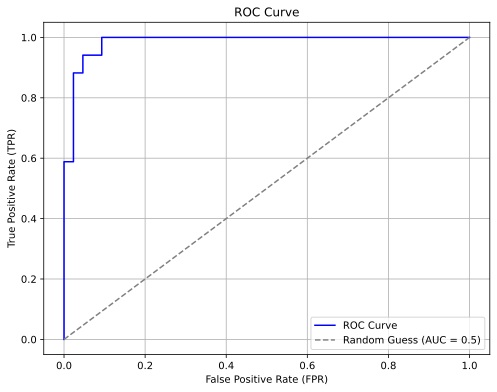

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(get_fprs, get_tprs, color='blue', label='ROC Curve')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

---

## **Threshold and ROC Curve**
- **Left side (top-left corner) → Higher thresholds**
  - Model is strict in classifying positives.
  - **Lower FPR, lower TPR**.
- **Right side (bottom-right corner) → Lower thresholds**
  - Model is lenient in classifying positives.
  - **Higher FPR, higher TPR**.

---

## **Interpreting the ROC Curve**
- A perfect classifier would have a point at (0,1), meaning **TPR = 1, FPR = 0**.
- A diagonal line from (0,0) to (1,1) represents **random guessing (AUC = 0.5)**.
- A model with a curve bending toward the top-left corner is better.

---

## **Example**
If a model predicts probabilities:
- **Threshold = 0.9 (left side, high threshold)**
  - Only very confident cases are classified as positive.
  - Fewer false positives but more false negatives.
- **Threshold = 0.1 (right side, low threshold)**
  - Many cases are classified as positive.
  - Higher recall (TPR), but also more false positives.

## Why AUC-ROC?

- **Evaluation Across Different Thresholds**:  
   The ROC curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) across a range of decision thresholds.  
   - As the threshold is adjusted (from 0 to 1), the classification boundary changes, impacting the predicted labels.  
   - The ROC curve helps visualize how the model’s performance (TPR and FPR) evolves with these threshold changes.

- **Understanding Trade-offs**:  
   By varying the threshold, the ROC curve shows the trade-offs between **sensitivity** (True Positive Rate) and **specificity** (False Positive Rate).  
   - A lower threshold increases sensitivity but may also increase false positives, while a higher threshold reduces false positives but might lower sensitivity.

- **Threshold-Independent Evaluation**:  
   The ROC curve is independent of the chosen threshold value, meaning it evaluates model performance across all thresholds.  
   - This is useful because it doesn't lock you into a specific decision boundary and shows how well the model differentiates between positive and negative classes over a range of thresholds.  

# Precision-Recall (PR) Curve

The **Precision-Recall (PR) curve** is a plot that visualizes the trade-off between **precision** and **recall** for different thresholds in binary classification. It is particularly useful when dealing with imbalanced datasets, where the positive class is much less frequent than the negative class.

---

## Key Definitions:

1. **Precision (P)**:  
   Precision is the ratio of true positives to the total predicted positives, indicating how many of the predicted positive instances are actually correct.
   $$
   \text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}
   $$

2. **Recall (R)**:  
   Recall, also known as **True Positive Rate (TPR)** or **Sensitivity**, is the ratio of true positives to the total actual positives, indicating how many of the actual positive instances were correctly identified.
   $$
   \text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}
   $$

3. **Threshold**:  
   Like the ROC curve, the PR curve is plotted across different thresholds. By varying the threshold, we adjust the decision boundary and calculate **precision** and **recall** for each threshold.

---

## Construction of the PR Curve:

1. **Calculate Precision and Recall**:  
   For each threshold (from 0 to 1), calculate:
   - **Precision**: The ratio of true positives to all predicted positives.
   - **Recall**: The ratio of true positives to all actual positives.

2. **Plot Precision vs. Recall**:  
   Plot the precision on the y-axis and recall on the x-axis for various thresholds. This will give a curve that represents the trade-off between precision and recall as the threshold is adjusted.

---

## Area Under the PR Curve (AUC-PR):

The **AUC-PR** (Area Under the Precision-Recall curve) is a summary statistic that quantifies the overall performance of the classifier:
- **Higher AUC-PR** values indicate better performance, where **AUC-PR = 1** represents a perfect classifier and **AUC-PR = 0.5** indicates random guessing.
  
Mathematically, **AUC-PR** is computed as the integral of the PR curve, similar to how the **AUC of the ROC curve** is calculated:
$$
\text{AUC-PR} = \int_0^1 \text{Precision}(\text{Recall}) \, d(\text{Recall})
$$

---

## Exercise: Plot the PR-curve for the problem at hand

---

## When is AUC-PR better than AUC-ROC?

   - **AUC-PR** is more informative in cases where the dataset is highly imbalanced, meaning there are significantly more negative samples (0s) than positive samples (1s).
   - In such cases, **AUC-ROC** can be misleading because it includes the **True Negative Rate (TNR)**, and the large number of true negatives can dominate the performance metrics, making the model appear to perform better than it really does.
   - **AUC-PR**, on the other hand, focuses only on the positive class and evaluates precision and recall, which are more meaningful in imbalanced datasets. This makes **AUC-PR** a better measure of classifier performance when the focus is on detecting the positive class in imbalanced data.
   

### True Labels ($y_{\text{true}}$):
Let the true labels represent whether each sample belongs to the positive class (1) or the negative class (0).

$$
y_{\text{true}} = [1, 1, 1, 0, 0, 0, 0, 0, 0, 0]
$$

Where:
- 1 represents a positive sample (3 positive samples),
- 0 represents a negative sample (7 negative samples).

### Predicted Probabilities ($y_{\text{pred_prob}}$):
Let the predicted probabilities represent the classifier’s output probabilities for each sample.

$$
y_{\text{pred_prob}} = [0.9, 0.8, 0.85, 0.2, 0.15, 0.1, 0.05, 0.3, 0.4, 0.05]
$$

Where:
- Higher values (e.g., 0.9, 0.8) suggest that the classifier believes the corresponding samples are more likely to be positive.
- Lower values (e.g., 0.05, 0.1) suggest a higher likelihood of those samples being negative.

---


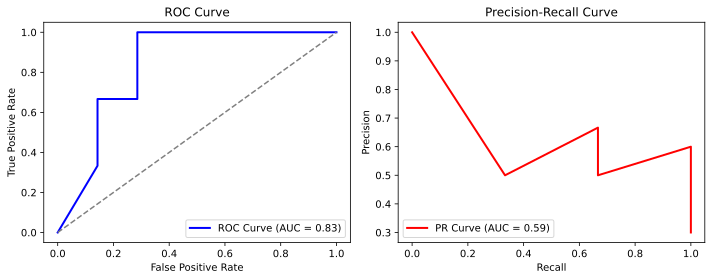

In [ ]:
# Sample true labels (3 positive, 7 negative) and predicted probabilities
y_true = np.array([1, 1, 1, 0, 0, 0, 0, 0, 0, 0])  # True labels
y_pred_prob = np.array([0.4, 0.33, 0.24, 0.2, 0.15, 0.1, 0.05, 0.3, 0.4, 0.05])  # Predicted probabilities

# Calculate ROC curve and ROC AUC
fpr, tpr, roc_thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Calculate Precision-Recall curve and PR AUC
precision, recall, pr_thresholds = precision_recall_curve(y_true, y_pred_prob)
pr_auc = average_precision_score(y_true, y_pred_prob)

# Plotting the ROC Curve
plt.figure(figsize=(10, 4))

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='b', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

# Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='r', lw=2, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')

# Display the plots
plt.tight_layout()
plt.show()

# **Multiclass Confusion Matrix**

In a **multiclass classification** problem, there are more than two classes. For each instance, the classifier makes a prediction about which class it belongs to. A **confusion matrix** for multiclass classification is a square matrix where:

- Rows represent the actual class labels.
- Columns represent the predicted class labels.

Each cell in the matrix represents the count of instances for a specific combination of true and predicted labels. For example, the cell at position $(i, j)$ represents the number of instances where the true class is $i$ and the predicted class is $j$.

## **Confusion Matrix Example:**

Consider a 3-class classification problem with the following confusion matrix:

|                 | Predicted Class 1 | Predicted Class 2 | Predicted Class 3 |
|-----------------|-------------------|-------------------|-------------------|
| **Actual Class 1** | 40                | 10                | 5                 |
| **Actual Class 2** | 8                 | 50                | 12                |
| **Actual Class 3** | 4                 | 15                | 60                |

Here:
- Class 1, Class 2, and Class 3 are the actual classes.
- The values in the matrix show how many instances were classified as each of the predicted classes.

## **Micro and Macro Scores**

In multiclass classification, we often compute metrics such as **precision**, **recall**, and **F1-score**. These metrics can be calculated in two main ways: **micro averaging** and **macro averaging**.

### **1. Micro-Averaged Scores**

Micro-averaged metrics treat all instances across classes as if they belong to a single binary classification task. It aggregates the counts of true positives (TP), false positives (FP), and false negatives (FN) across all classes, and then computes the metrics based on these aggregated counts.

- **Micro Precision**:
  $$
  \text{Micro Precision} = \frac{\sum_{i} TP_i}{\sum_{i} TP_i + \sum_{i} FP_i}
  $$

- **Micro Recall**:
  $$
  \text{Micro Recall} = \frac{\sum_{i} TP_i}{\sum_{i} TP_i + \sum_{i} FN_i}
  $$

- **Micro F1-Score**:
  $$
  \text{Micro F1} = 2 \times \frac{\text{Micro Precision} \times \text{Micro Recall}}{\text{Micro Precision} + \text{Micro Recall}}
  $$

The micro-averaging method gives equal weight to each instance, rather than each class. It is especially useful when the dataset is imbalanced, as it evaluates the classifier’s performance over all samples in total.

### **2. Macro-Averaged Scores**

Macro-averaged metrics compute the score for each class individually and then take the average. This method treats all classes equally, regardless of their size.

- **Macro Precision**:
  $$
  \text{Macro Precision} = \frac{1}{C} \sum_{i=1}^{C} \frac{TP_i}{TP_i + FP_i}
  $$

- **Macro Recall**:
  $$
  \text{Macro Recall} = \frac{1}{C} \sum_{i=1}^{C} \frac{TP_i}{TP_i + FN_i}
  $$

- **Macro F1-Score**:
  $$
  \text{Macro F1} = \frac{1}{C} \sum_{i=1}^{C} \frac{2 \times \text{Precision}_i \times \text{Recall}_i}{\text{Precision}_i + \text{Recall}_i}
  $$

The macro-averaging method computes the performance for each class independently, which can be helpful when you want to measure performance in a class-agnostic way (i.e., ensuring that each class has equal importance).

## **Key Differences Between Micro and Macro Scores**

- **Micro averaging** focuses on the total number of correct predictions across all classes, giving more weight to the classes with more instances.
- **Macro averaging** computes metrics independently for each class and averages them, giving equal weight to each class, regardless of its size.

## **Mathematical Explanation with a 3-Class Example:**

Consider the following confusion matrix for a 3-class problem:

|                 | Predicted Class 1 | Predicted Class 2 | Predicted Class 3 |
|-----------------|-------------------|-------------------|-------------------|
| **Actual Class 1** | 40                | 10                | 5                 |
| **Actual Class 2** | 8                 | 50                | 12                |
| **Actual Class 3** | 4                 | 15                | 60                |

We can calculate the precision, recall, and F1-score for each class and then average them.

### **Step 1: Calculate Precision and Recall for each class**

- **Precision for Class 1**:
  $$
  \text{Precision}_1 = \frac{TP_1}{TP_1 + FP_1} = \frac{40}{40 + 8 + 4} = \frac{40}{52} \approx 0.769
  $$

- **Recall for Class 1**:
  $$
  \text{Recall}_1 = \frac{TP_1}{TP_1 + FN_1} = \frac{40}{40 + 10 + 5} = \frac{40}{55} \approx 0.727
  $$

- **Precision for Class 2**:
  $$
  \text{Precision}_2 = \frac{50}{50 + 10 + 15} = \frac{50}{75} \approx 0.667
  $$

- **Recall for Class 2**:
  $$
  \text{Recall}_2 = \frac{50}{50 + 8 + 12} = \frac{50}{70} \approx 0.714
  $$

- **Precision for Class 3**:
  $$
  \text{Precision}_3 = \frac{60}{60 + 12 + 5} = \frac{60}{77} \approx 0.779
  $$

- **Recall for Class 3**:
  $$
  \text{Recall}_3 = \frac{60}{60 + 4 + 15} = \frac{60}{79} \approx 0.759
  $$

### **Step 2: Calculate Micro Scores**

- **Micro Precision**:
  $$
  \text{Micro Precision} = \frac{\sum TP}{\sum TP + \sum FP} = \frac{40 + 50 + 60}{(40 + 8 + 4) + (50 + 10 + 15) + (60 + 12 + 5)} = \frac{150}{(52 + 75 + 77)} \approx 0.689
  $$

- **Micro Recall**:
  $$
  \text{Micro Recall} = \frac{\sum TP}{\sum TP + \sum FN} = \frac{150}{(55 + 70 + 79)} = \frac{150}{204} \approx 0.735
  $$

### **Step 3: Calculate Macro Scores**

- **Macro Precision**:
  $$
  \text{Macro Precision} = \frac{1}{3} \left( \text{Precision}_1 + \text{Precision}_2 + \text{Precision}_3 \right) = \frac{1}{3} \left( 0.769 + 0.667 + 0.779 \right) \approx 0.738
  $$

- **Macro Recall**:
  $$
  \text{Macro Recall} = \frac{1}{3} \left( \text{Recall}_1 + \text{Recall}_2 + \text{Recall}_3 \right) = \frac{1}{3} \left( 0.727 + 0.714 + 0.759 \right) \approx 0.733
  $$

---

## **Summary of Metrics:**

| Metric        | Micro Average | Macro Average |
|---------------|---------------|---------------|
| Precision     | 0.689         | 0.738         |
| Recall        | 0.735         | 0.733         |
| F1-Score      | 0.711         | 0.735         |
